# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import re   

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [2]:
url = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv'

df = pd.read_csv(url)

### Step 3. Assign it to a variable apple and apply a head()

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 4.  Check out the type of the columns

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       8465 non-null   object 
 1   Open       8465 non-null   float64
 2   High       8465 non-null   float64
 3   Low        8465 non-null   float64
 4   Close      8465 non-null   float64
 5   Volume     8465 non-null   int64  
 6   Adj Close  8465 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 463.1+ KB


### Step 5. Transform the Date column as a datetime type and check the info()

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8465 non-null   datetime64[ns]
 1   Open       8465 non-null   float64       
 2   High       8465 non-null   float64       
 3   Low        8465 non-null   float64       
 4   Close      8465 non-null   float64       
 5   Volume     8465 non-null   int64         
 6   Adj Close  8465 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 463.1 KB


### Step 6.  Set the date as the index

In [9]:
df.set_index('Date', inplace=True)

### Step 7.  Is there any duplicate dates?

In [ ]:
df.index.is_unique

# para unificar datas usar mixed y leugo comparar las que han quedado diferentes para ver lo que ha podido pasar

True

NO HAY FEACHAS DUPLICADAS

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [12]:
df.sort_index(ascending=True, inplace=True)

### Step 9. Get the last business day of each month

In [ ]:
df_monthly = df.resample('BME').last()
df_monthly.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,34.25,34.25,34.13,34.13,8937600,0.53
1981-01-30,28.50,28.50,28.25,28.25,11547200,0.44
1981-02-27,26.50,26.75,26.50,26.50,3690400,0.41
1981-03-31,24.75,24.75,24.50,24.50,3998400,0.38
1981-04-30,28.38,28.62,28.38,28.38,3152800,0.44


### Step 10.  What is the difference in days between the first day and the oldest

In [18]:
diferencia = (df.index.max() - df.index.min()).days

print(diferencia)

12261


### Step 11.  How many months in the data we have?

In [26]:
meses= df.index.to_period('M').nunique()

print(meses)

404


### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

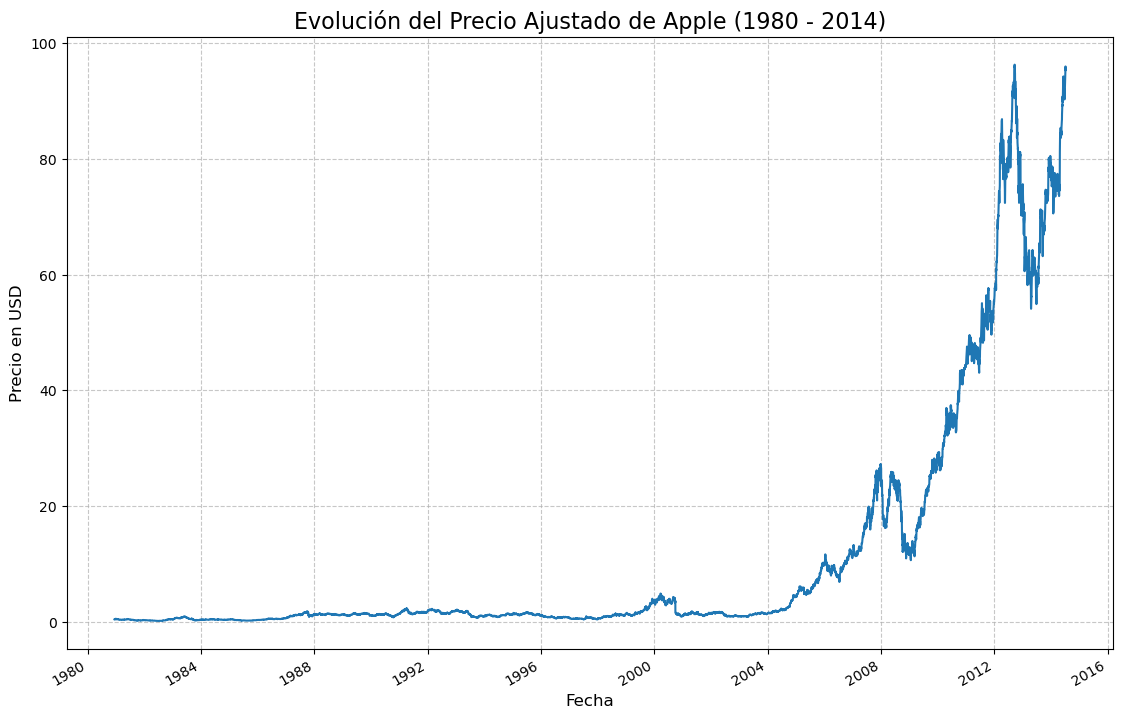

In [27]:
import matplotlib.pyplot as plt

# 1. Definimos el tamaño de la figura (ancho x alto en pulgadas)
# 2. Seleccionamos la columna 'Adj Close'
# 3. Añadimos etiquetas para que el gráfico sea legible
plt.figure(figsize=(13.5, 9))
df['Adj Close'].plot()

# Personalización del gráfico
plt.title('Evolución del Precio Ajustado de Apple (1980 - 2014)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio en USD', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Añadir una rejilla ayuda a la lectura

# Mostramos el gráfico
plt.show()